### **Project: Olist E-commerce SQL Analytics**

This notebook contains EDA of the [Brazilian E-Commerce dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). I chose a Jupyter notebook-based approach over standard SQL scripts because it allows me to seamlessly query data via DB files/DBMS connection while keeping the results preserved in one place. This makes it much easier to iterate on complex analysis and communicate insights without needing an external BI tool or a separate environment.

I used the ddb file from one of my other [Datawarehouse project](https://github.com/RahulShinde02/SQL-data-warehouse-Projects/tree/main/olist_datawarehouse) where I designed and cleaned it in medallion architecture

**What I covered:**

* **Analytical SQL:** Used window functions, CTEs, and `NTILE` for things like cohort retention, RFM segmentation, and Pareto analysis.
* **Key Findings:**
* **Retention:** We have a "leaky bucket" problem—retention drops off immediately, making us almost entirely dependent on new customer acquisition.
* **Logistics:** The real bottleneck isn't the seller dispatching the item; it’s the carrier transit time, which correlates directly with 1-star reviews.
* **Pareto:** The business is heavily reliant on a small slice of the catalog; 16 categories drive nearly 80% of total revenue.
* **Payment Behavior:** There is a clear link between high-value orders and credit card financing—the more expensive the item, the more installments the customer needs to close the deal.


#### Libraries used
* pandas
* duckdb
* jupytersql
* matplotlib
* seaborn

In [1]:
%load_ext sql

In [2]:
%sql duckdb:///olist_datawarehouse.duckdb
# here we are connecting db file to notebook using Jupysql extension

Connecting to 'duckdb:///olist_datawarehouse.duckdb'

In [3]:
%config SqlMagic.displaylimit = 100

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
%%sql
SELECT * FROM information_schema.tables Where
    table_schema = 'gold' OR table_schema = 'silver';

Running query in 'duckdb:///olist_datawarehouse.duckdb'

table_catalog,table_schema,table_name,table_type,self_referencing_column_name,reference_generation,user_defined_type_catalog,user_defined_type_schema,user_defined_type_name,is_insertable_into,is_typed,commit_action,TABLE_COMMENT
olist_datawarehouse,gold,dim_customers,BASE TABLE,None,None,None,None,None,YES,NO,None,None
olist_datawarehouse,gold,dim_geolocation,BASE TABLE,None,None,None,None,None,YES,NO,None,None
olist_datawarehouse,gold,dim_sellers,BASE TABLE,None,None,None,None,None,YES,NO,None,None
olist_datawarehouse,gold,fact_order,BASE TABLE,None,None,None,None,None,YES,NO,None,None
olist_datawarehouse,gold,fact_order_list,BASE TABLE,None,None,None,None,None,YES,NO,None,None
olist_datawarehouse,silver,olist_customers,BASE TABLE,None,None,None,None,None,YES,NO,None,None
olist_datawarehouse,silver,olist_geolocation,BASE TABLE,None,None,None,None,None,YES,NO,None,None
olist_datawarehouse,silver,olist_orders,BASE TABLE,None,None,None,None,None,YES,NO,None,None
olist_datawarehouse,silver,olist_order_items,BASE TABLE,None,None,None,None,None,YES,NO,None,None
olist_datawarehouse,silver,olist_order_payments,BASE TABLE,None,None,None,None,None,YES,NO,None,None


In [6]:
'''%%sql
SELECT * FROM information_schema.columns WHERE
  table_schema = 'gold' OR table_schema = 'silver'
'''

"%%sql\nSELECT * FROM information_schema.columns WHERE\n  table_schema = 'gold' OR table_schema = 'silver'\n"

In [7]:
%sql rollback

Running query in 'duckdb:///olist_datawarehouse.duckdb'

Success


### Q1.1: Cohort Retention Analysis

* **Business Problem:** The marketing team wants to know if customers acquired in early 2017 are more loyal than those acquired later.
* **SQL Requirement:** Group customers into monthly cohorts based on their first purchase date. Calculate the percentage of those customers who made a repeat purchase in subsequent months (Month 1, Month 2, Month 3, up to Month 12).

#### -->
- **Objective:** Seeing if we’re actually building a sticky product or just relying on one-off acquisitions.
- **Logic:** A cohort is anchored to the month of the user’s first-ever purchase. This tracks their repeat purchase activity over the first 12 months to measure long-term value.
- **Output:** A retention matrix table showing the % of customers coming back—essentially telling us if our acquisition strategy is sustainable.

In [8]:
%%sql
WITH cohort_customers AS (
SELECT
c.customer_unique_id,
DATE_TRUNC('month', MIN(o.order_purchase_timestamp)) AS cohort_month
FROM gold.dim_customers c
LEFT JOIN gold.fact_order o ON o.customer_id = c.customer_id
GROUP BY c.customer_unique_id
),
cohort_index AS (
SELECT
cc.cohort_month,
cc.customer_unique_id,
DATEDIFF('month', cc.cohort_month, DATE_TRUNC('month', o.order_purchase_timestamp)) AS cindex
FROM cohort_customers cc
JOIN gold.dim_customers dc ON cc.customer_unique_id = dc.customer_unique_id
JOIN gold.fact_order o ON o.customer_id = dc.customer_id
),
raw_counts AS (
SELECT
cohort_month,
CAST(COUNT(DISTINCT CASE WHEN cindex = 0 THEN customer_unique_id END) AS DOUBLE) AS base,
COUNT(DISTINCT CASE WHEN cindex = 1 THEN customer_unique_id END) AS m1,
COUNT(DISTINCT CASE WHEN cindex = 2 THEN customer_unique_id END) AS m2,
COUNT(DISTINCT CASE WHEN cindex = 3 THEN customer_unique_id END) AS m3,
COUNT(DISTINCT CASE WHEN cindex = 4 THEN customer_unique_id END) AS m4,
COUNT(DISTINCT CASE WHEN cindex = 5 THEN customer_unique_id END) AS m5,
COUNT(DISTINCT CASE WHEN cindex = 6 THEN customer_unique_id END) AS m6,
COUNT(DISTINCT CASE WHEN cindex = 7 THEN customer_unique_id END) AS m7,
COUNT(DISTINCT CASE WHEN cindex = 8 THEN customer_unique_id END) AS m8,
COUNT(DISTINCT CASE WHEN cindex = 9 THEN customer_unique_id END) AS m9,
COUNT(DISTINCT CASE WHEN cindex = 10 THEN customer_unique_id END) AS m10,
COUNT(DISTINCT CASE WHEN cindex = 11 THEN customer_unique_id END) AS m11,
COUNT(DISTINCT CASE WHEN cindex = 12 THEN customer_unique_id END) AS m12
FROM cohort_index
GROUP BY cohort_month
)
SELECT
STRFTIME(cohort_month, '%Y-%m') AS DATE,
base,
ROUND((m1 / NULLIF(base, 0)) * 100, 2) AS month_1,
ROUND((m2 / NULLIF(base, 0)) * 100, 2) AS month_2,
ROUND((m3 / NULLIF(base, 0)) * 100, 2) AS month_3,
ROUND((m4 / NULLIF(base, 0)) * 100, 2) AS month_4,
ROUND((m5 / NULLIF(base, 0)) * 100, 2) AS month_5,
ROUND((m6 / NULLIF(base, 0)) * 100, 2) AS month_6,
ROUND((m7 / NULLIF(base, 0)) * 100, 2) AS month_7,
ROUND((m8 / NULLIF(base, 0)) * 100, 2) AS month_8,
ROUND((m9 / NULLIF(base, 0)) * 100, 2) AS month_9,
ROUND((m10 / NULLIF(base, 0)) * 100, 2) AS month_10,
ROUND((m11 / NULLIF(base, 0)) * 100, 2) AS month_11,
ROUND((m12 / NULLIF(base, 0)) * 100, 2) AS month_12
FROM raw_counts
WHERE cohort_month >= '2017-01-01'
ORDER BY cohort_month;

Running query in 'duckdb:///olist_datawarehouse.duckdb'

DATE,base,month_1,month_2,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
2017-01,764.0,0.39,0.26,0.13,0.39,0.13,0.52,0.13,0.13,0.0,0.39,0.13,0.79
2017-02,1752.0,0.23,0.29,0.11,0.4,0.11,0.23,0.17,0.17,0.23,0.11,0.29,0.17
2017-03,2636.0,0.49,0.38,0.38,0.34,0.15,0.15,0.3,0.34,0.08,0.38,0.15,0.23
2017-04,2352.0,0.6,0.21,0.17,0.34,0.26,0.34,0.3,0.3,0.17,0.26,0.09,0.09
2017-05,3596.0,0.5,0.5,0.39,0.31,0.33,0.42,0.17,0.25,0.31,0.25,0.33,0.25
2017-06,3139.0,0.48,0.35,0.41,0.25,0.38,0.38,0.22,0.13,0.22,0.32,0.35,0.16
2017-07,3894.0,0.51,0.36,0.26,0.28,0.21,0.31,0.1,0.18,0.26,0.23,0.31,0.13
2017-08,4184.0,0.69,0.33,0.26,0.36,0.53,0.29,0.26,0.14,0.14,0.24,0.19,0.1
2017-09,4130.0,0.68,0.53,0.29,0.46,0.22,0.22,0.24,0.29,0.17,0.27,0.07,0.0
2017-10,4470.0,0.69,0.25,0.09,0.22,0.2,0.22,0.36,0.27,0.2,0.2,0.0,0.0


In [9]:
# the jupyter nb stores output of last executed cell into placeholder variable '_' 
# so we can use it to create a df & visualize it using a heatmap.
cohort_df = _.DataFrame()

In [10]:
retention_matrix = cohort_df.set_index('DATE')
retention_matrix = retention_matrix.drop(columns=['base'])

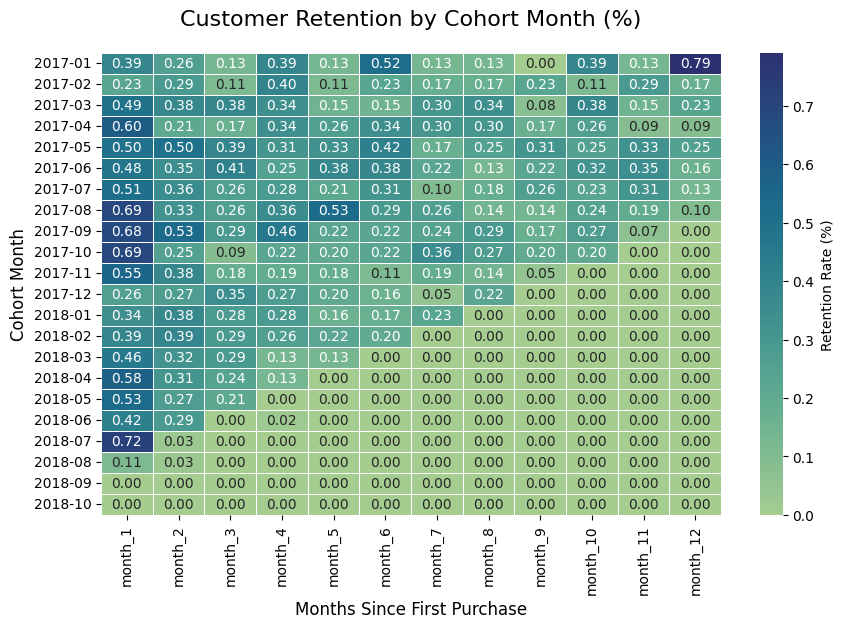

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(retention_matrix,annot=True, fmt=".2f",cmap="crest",
            linewidths=0.5,cbar_kws={'label': 'Retention Rate (%)'})

plt.title('Customer Retention by Cohort Month (%)', fontsize=16, pad=20)
plt.ylabel('Cohort Month', fontsize=12)
plt.xlabel('Months Since First Purchase', fontsize=12)
plt.yticks(rotation=0)
plt.show()

# Insights
* **Hypothesis Rejected:** Early 2017 customers are **not** more loyal than later ones.
* **Critical Retention Issue:** The business has a severe "leaky bucket" problem. Retention rates are drastically low, remaining below **1%** across all cohorts and months. The platform relies almost entirely on one-time transactional buyers.
* **Volume vs. Stickiness:** Acquisition scaled significantly—surging from **764** users (Jan 2017) to a peak of **7,304** users (Nov 2017)—but cohort stickiness remained completely flat.

### Q1.2: RFM Segmentation (Recency, Frequency, Monetary)
* **Business Problem:** We need to segment our customer base to target them with personalized email campaigns.
* **SQL Requirement:** For every unique customer, calculate:
* **Recency:** Days between their most recent order and the maximum order date in the entire dataset.
* **Frequency:** Total number of distinct orders placed.
* **Monetary:** Total amount spent on order items.
* Assign a score from 1 to 5 for each metric using NTILE, and combine them to classify customers into buckets like "Champions", "At Risk", and "Lost".

#### -->
- **Objective:** Breaking the customer base down into actionable segments so we don't treat a "Champion" the same way we treat an "At-Risk" customer.
- **Logic:** Using `NTILE(5)` to rank customers by Recency, Frequency, and Monetary value. It’s a standard move to prioritize who gets VIP treatment and who needs re-engagement campaigns.
- **Output:** A tagged dataset that categorizes users into labels like "Champions," "Loyal,", "At Risk," and some other segments making it easy to target marketing spend.

In [12]:
%%sql
WITH rfm_base AS (
SELECT
cust.customer_unique_id,
DATEDIFF('day', MAX(ord.order_purchase_timestamp), (SELECT MAX(order_purchase_timestamp) FROM gold.fact_order)) AS recency_days,
COUNT(DISTINCT ord.order_id) AS frequency_count,
SUM(ord.total_payment_value) AS monetary_value
FROM gold.dim_customers cust
JOIN gold.fact_order ord ON cust.customer_id = ord.customer_id
GROUP BY cust.customer_unique_id
),
rfm_ntiles AS (
SELECT
customer_unique_id,
recency_days,
frequency_count,
monetary_value,
NTILE(5) OVER (ORDER BY recency_days DESC) AS r_score,
NTILE(5) OVER (ORDER BY frequency_count ASC) AS f_score,
NTILE(5) OVER (ORDER BY monetary_value ASC) AS m_score
FROM rfm_base
)
SELECT
customer_unique_id,
recency_days,
frequency_count,
monetary_value,
r_score,
f_score,
m_score,
(r_score * 100 + f_score * 10 + m_score) AS rfm_score,
CASE
WHEN r_score >= 4 AND f_score >= 4 AND m_score >= 4 THEN 'Champions'
WHEN r_score >= 3 AND f_score >= 3 AND m_score >= 3 THEN 'Loyal'
WHEN r_score >= 4 AND f_score <= 2 THEN 'New'
WHEN r_score <= 2 AND f_score >= 4 THEN 'At Risk'
WHEN r_score <= 1 THEN 'Lost'
ELSE 'Average'
END AS customer_segment
FROM rfm_ntiles
ORDER BY monetary_value DESC;

Running query in 'duckdb:///olist_datawarehouse.duckdb'

customer_unique_id,recency_days,frequency_count,monetary_value,r_score,f_score,m_score,rfm_score,customer_segment
0a0a92112bd4c708ca5fde585afaa872,383,1,13664.08,2,4,5,245,At Risk
46450c74a0d8c5ca9395da1daac6c120,61,3,9553.02,5,5,5,555,Champions
da122df9eeddfedc1dc1f5349a1a690c,564,2,7571.63,1,5,5,155,At Risk
763c8b1c9c68a0229c42c9fc6f662b93,94,1,7274.88,5,4,5,545,Champions
dc4802a71eae9be1dd28f5d788ceb526,612,1,6929.31,1,3,5,135,Lost
459bef486812aa25204be022145caa62,84,1,6922.21,5,4,5,545,Champions
ff4159b92c40ebe40454e3e6a7c35ed6,511,1,6726.66,1,5,5,155,At Risk
4007669dec559734d6f53e029e360987,327,1,6081.54,2,1,5,215,Average
5d0a2980b292d049061542014e8960bf,97,1,4809.44,5,4,5,545,Champions
eebb5dda148d3893cdaf5b5ca3040ccb,547,1,4764.34,1,4,5,145,At Risk


### Q2.1: Delivery Under-Performance and Bottlenecks

* **Business Problem:** Customers are complaining about late deliveries. We need to isolate where the delay happens: is it the seller taking too long to ship, or the carrier taking too long to deliver?
* **SQL Requirement:** Write a query that computes three metrics for every completed order:
1. **Shipping Delay:** Days between order approval and when the seller hands it over to the carrier (`shipping_limit_date` vs `order_delivered_carrier_date`).
2. **Carrier Transit Time:** Days between carrier pickup and final delivery (`order_delivered_carrier_date` vs `order_delivered_customer_date`).
3. **Estimated vs Actual:** Days difference between estimated delivery date and final actual delivery.


* Filter the results to show the top 100 worst-performing orders and check if there is a correlation with low review scores.


#### -->
- **Objective:** Finding out where the delivery process is failing. Is it the seller slow-rolling the dispatch, or is the courier dragging their feet?
- **Logic:** We're separating seller fulfillment time from transit time. It filters out anomalies so we can see the real operational delays impacting customer satisfaction.
- **Output:** A ranked view of the worst delivery experiences, identifying whether the bottleneck is on the seller side or the transit side.

In [13]:
%%sql
SELECT
order_id,
review_score,
DATEDIFF('day', order_approved_at, order_delivered_carrier_date) AS shipping_delay_days,
DATEDIFF('day', order_delivered_carrier_date, order_delivered_customer_date) AS carrier_transit_days,
DATEDIFF('day', order_estimated_delivery_date, order_delivered_customer_date) AS days_past_estimate
FROM gold.fact_order
WHERE order_status = 'delivered'
AND order_approved_at IS NOT NULL
AND order_delivered_carrier_date IS NOT NULL
AND order_delivered_customer_date IS NOT NULL
AND bad_delivery IS FALSE
AND bad_carrier IS FALSE
ORDER BY days_past_estimate DESC;

Running query in 'duckdb:///olist_datawarehouse.duckdb'

order_id,review_score,shipping_delay_days,carrier_transit_days,days_past_estimate
1b3190b2dfa9d789e1f14c05b647a14a,2.0,3,205,188
ca07593549f1816d26a572e06dc1eab6,0.0,13,195,181
47b40429ed8cce3aee9199792275433f,1.0,34,157,175
2fe324febf907e3ea3f2aa9650869fa5,1.0,4,186,167
285ab9426d6982034523a855f55a885e,1.0,1,194,166
440d0d17af552815d15a9e41abe49359,1.0,6,188,165
c27815f7e3dd0b926b58552628481575,3.0,6,182,162
0f4519c5f1c541ddec9f21b3bddd533a,4.0,13,181,161
d24e8541128cea179a11a65176e0a96f,4.0,4,171,161
2d7561026d542c8dbd8f0daeadf67a43,3.0,1,187,159


# Insights

* **Carrier Transit is the Core Bottleneck:** In this worst-performing sample, the bottleneck is overwhelmingly driven by the shipping carriers rather than seller fulfillment delays.
* The majority of sellers hand over goods to logistics partners within **0 to 5 days** (`shipping_delay_days`).
* Conversely, carriers are holding onto packages in transit for extreme durations, frequently stretching between **80 to 200+ days** (`carrier_transit_days`).
* **Correlation with Review Scores:** * As expected, a significant volume of these severely delayed orders result in **1.0 and 0.0 review scores**, explicitly matching the business problem of customer complaints regarding lateness.


### Q2.2: Geographic Freight Cost Disparities

* **Business Problem:** Shipping costs across Brazil vary wildly due to the country's massive geography.
* **SQL Requirement:** Calculate the average freight value, average product price, and the ratio of freight-to-product cost for orders shipped from sellers in São Paulo (`SP`) to buyers in northern, remote states like Acre (`AC`), Amazonas (`AM`), and Roraima (`RR`). Compare this against the same metrics for internal São Paulo transactions.


#### -->
- **Objective:** Checking if shipping to remote regions (like the North) is eating our margins compared to local deliveries.
- **Logic:** Comparing internal São Paulo shipping costs against remote states (AC, AM, RR). It exposes whether remote logistics make specific product categories non-viable.
- **Output:** A side-by-side comparison of price vs. freight cost, showing if shipping distance is creating a "margin drain" for certain routes.

In [14]:
%%sql
WITH freight_base AS (
SELECT
l.order_id,
l.price,
l.freight_value,
c.customer_state,
s.seller_state
FROM gold.fact_order_list l
JOIN gold.fact_order o ON l.order_id = o.order_id
JOIN gold.dim_customers c ON o.customer_id = c.customer_id
JOIN gold.dim_sellers s ON l.seller_id = s.seller_id
WHERE o.order_status = 'delivered'
),
routes AS (
SELECT
order_id,
price,
freight_value,
CASE
WHEN seller_state = 'SP' AND customer_state IN ('AC', 'AM', 'RR') THEN 'SP to (AC, AM, RR)'
WHEN seller_state = 'SP' AND customer_state = 'SP' THEN 'Internal São Paulo'
ELSE 'Other Routes'
END AS shipping_route
FROM freight_base
)
SELECT
shipping_route,
COUNT(DISTINCT order_id) AS total_orders,
ROUND(AVG(price), 2) AS avg_product_price,
ROUND(AVG(freight_value), 2) AS avg_freight_value,
ROUND((AVG(freight_value) / NULLIF(AVG(price), 0)) * 100, 2) AS freight_to_product_ratio_pct
FROM routes
WHERE shipping_route != 'Other Routes'
GROUP BY shipping_route
ORDER BY avg_freight_value DESC;

Running query in 'duckdb:///olist_datawarehouse.duckdb'

shipping_route,total_orders,avg_product_price,avg_freight_value,freight_to_product_ratio_pct
"SP to (AC, AM, RR)",189,137.63,35.4,25.72
Internal São Paulo,30834,99.44,13.2,13.27


# Insights

* **Massive Freight Cost Premium:** Shipping from São Paulo to the remote northern states (AC, AM, RR) incurs a **168% increase in freight costs** compared to local shipping (R$ 35.40 vs. R$ 13.20).
* **The Margin Squeeze (Freight-to-Product Ratio):** * For local transactions within SP, the freight represents an acceptable **13.27%** of the product price.
* For northern transactions, freight consumes a massive **25.72%** of the item's value. This structural cost makes lower-priced retail items completely unviable for northern buyers.

### Q3.1: Product Category Pareto Analysis (The 80/20 Rule)

* **Business Problem:** The inventory team wants to focus optimization efforts on the categories driving the vast majority of revenue.
* **SQL Requirement:** Calculate the total revenue generated by each product category. Use a window function to compute the running cumulative percentage of total revenue across all categories. Filter the query to display only the top categories that make up the first 80% of Olist's aggregate revenue.
* **Advanced Concepts Needed:** Cumulative window function (`SUM() OVER (ORDER BY ... ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)`), Subqueries/CTEs to evaluate the percentage filter.

#### -->
- **Objective:** Applying the 80/20 rule to our product portfolio. We need to know which categories actually drive the business.
- **Logic:** Ranking categories by revenue and using a running window function to find the "Top 80%" revenue drivers.
- **Output:** A focused list showing us exactly which product categories we should be doubling down on for inventory and marketing.

In [15]:
%%sql
WITH category_revenue AS (
SELECT
product_category,
SUM(total_item_value) AS total_revenue
FROM gold.fact_order_list l
JOIN gold.fact_order o ON l.order_id = o.order_id
WHERE o.order_status = 'delivered'
AND product_category IS NOT NULL
GROUP BY product_category
),
running_pct AS (
SELECT
product_category,
total_revenue,
SUM(total_revenue) OVER (ORDER BY total_revenue DESC) AS cumulative_revenue,
SUM(total_revenue) OVER () AS aggregate_revenue,
ROUND((SUM(total_revenue) OVER (ORDER BY total_revenue DESC) / SUM(total_revenue) OVER ()) * 100, 2) AS cumulative_percentage
FROM category_revenue
)
SELECT
product_category,
ROUND(total_revenue, 2) AS category_revenue,
ROUND(cumulative_percentage, 2) AS cumulative_percentage
FROM running_pct
WHERE cumulative_percentage <= 80.00
OR (cumulative_percentage > 80.00 AND (cumulative_percentage - ((total_revenue / aggregate_revenue) * 100)) < 80.00)
ORDER BY total_revenue DESC;

Running query in 'duckdb:///olist_datawarehouse.duckdb'

product_category,category_revenue,cumulative_percentage
health_beauty,1412089.53,9.28
watches_gifts,1264333.12,17.58
bed_bath_table,1225209.26,25.63
sports_leisure,1118256.91,32.98
computers_accessories,1032723.77,39.76
furniture_decor,880329.92,45.55
housewares,758392.25,50.53
cool_stuff,691680.89,55.07
auto,669454.75,59.47
garden_tools,567145.68,63.2


In [16]:
pareto_df = _.DataFrame()

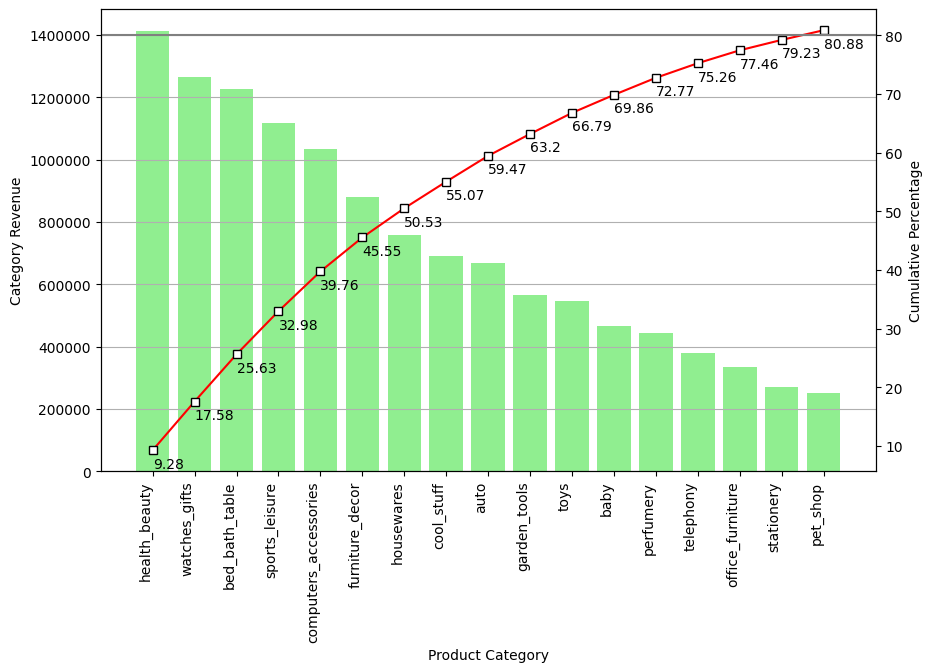

In [17]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.bar(pareto_df['product_category'],pareto_df['category_revenue'],color='lightgreen')
ax1.set_xticks(range(len(pareto_df)))
ax1.set_xticklabels(pareto_df['product_category'], rotation=90, ha='right')
ax1.ticklabel_format(axis='y',style='plain')
ax1.grid(axis='y')
ax1.set_xlabel('Product Category')
ax1.set_ylabel('Category Revenue')
ax2 = ax1.twinx()
ax2.plot(pareto_df['product_category'],pareto_df['cumulative_percentage'],marker='s',
        mfc='w',mec='k',color='r')
for i,v in zip(pareto_df['product_category'],pareto_df['cumulative_percentage']):
    plt.text(i,v-3,f'{v}')
ax2.set_ylabel('Cumulative Percentage')
ax2.axhline(80,color='grey')
plt.show()

# Insights

* **Strict Pareto Validation:** The dataset strictly conforms to the 80/20 rule. Out of approximately 70+ product categories available on Olist, just **16 categories** generate **79.23%** of the platform's aggregate revenue.
* **The Core Revenue Drivers:** The top 5 core categories (`health_beauty`, `watches_gifts`, `bed_bath_table`, `sports_leisure`, and `computers_accessories`) are massive engines, single-handedly accounting for nearly **40% (39.76%)** of all revenue.

### Q3.2: Payment Method Preferences & Installment Risk

* **Business Problem:** Brazilian shoppers heavily rely on paying in installments (*parcelas*). We want to understand the relationship between product cost, selected payment methods, and installment choices.
* **SQL Requirement:** Categorize orders by value tiers  `< $50`, `$50-$200`, `>$200`. For each tier, calculate the percentage breakdown of payment methods used (credit card, *boleto*, voucher, debit card). For the credit card segment, find the average number of installments preferred based on the transaction size.

#### -->
**Objective:** Understanding liquidity and payment behavior. Are we driving revenue through credit installments (which might indicate cash flow friction) or immediate payment types?
    
**Logic:** Aggregating order volume and total value by `payment_type` and `payment_installments`. This helps us see if certain customer segments prefer high-installment plans, which can impact the platform's financial risk and settlement cycles.
    
**Output:** A breakdown showing the distribution of payment methods and installment counts—essential for assessing the financial health of the transaction flow.

In [18]:
%%sql
WITH value_tiers AS (
SELECT
l.order_id,
SUM(l.total_item_value + l.freight_value) AS total_order_value
FROM gold.fact_order_list l
GROUP BY l.order_id
),
payments AS (
SELECT
t.order_id,
t.total_order_value,
CASE
WHEN t.total_order_value < 50.00 THEN '1. Low Value (< $50)'
WHEN t.total_order_value BETWEEN 50.00 AND 200.00 THEN '2. Medium Value ($50-$200)'
ELSE '3. High Value (> $200)'
END AS order_tier,
p.payment_type,
p.payment_value,
p.payment_installments
FROM value_tiers t
JOIN silver.olist_order_payments p ON t.order_id = p.order_id
)
SELECT
order_tier,
COUNT(DISTINCT order_id) AS total_orders,
ROUND((SUM(CASE WHEN payment_type = 'credit_card' THEN payment_value ELSE 0 END) / SUM(payment_value)) * 100, 2) AS credit_card_share_pct,
ROUND((SUM(CASE WHEN payment_type = 'boleto' THEN payment_value ELSE 0 END) / SUM(payment_value)) * 100, 2) AS boleto_share_pct,
ROUND((SUM(CASE WHEN payment_type = 'voucher' THEN payment_value ELSE 0 END) / SUM(payment_value)) * 100, 2) AS voucher_share_pct,
ROUND((SUM(CASE WHEN payment_type = 'debit_card' THEN payment_value ELSE 0 END) / SUM(payment_value)) * 100, 2) AS debit_card_share_pct,
ROUND(AVG(CASE WHEN payment_type = 'credit_card' THEN payment_installments END), 1) AS avg_cc_installments
FROM payments
GROUP BY order_tier
ORDER BY order_tier ASC;

Running query in 'duckdb:///olist_datawarehouse.duckdb'

order_tier,total_orders,credit_card_share_pct,boleto_share_pct,voucher_share_pct,debit_card_share_pct,avg_cc_installments
1. Low Value (< $50),7895,68.9,24.37,4.48,2.24,1.5
2. Medium Value ($50-$200),65437,75.8,19.74,2.98,1.47,3.0
3. High Value (> $200),25333,80.45,16.61,1.68,1.26,5.3


# Insights

* **Credit Card Dominance Scales with Order Value:** As ticket size increases, buyers lean more heavily on credit cards. Credit card share jumps from **68.9%** for low-value purchases to **80.45%** for high-value purchases over $200.

* **Direct Linear Correlation with Installments:** The dependency on financing (*parcelas*) is glaringly obvious.
* Small purchases ($< \$50$) are mostly paid upfront or settled quickly, averaging just **1.5 installments**.
* Expensive items ($> \$200$) strictly require structured financing, jumping to an average of **5.3 installments**.

### Q4.1: The Impact of Fulfillment Speed on Review Scores

* **Business Problem:** Prove quantitatively how fast delivery drives 5-star reviews, and how late delivery triggers 1-star reviews.
* **SQL Requirement:** Create a summary table grouped by `review_score` (1 through 5). For each score group, calculate:
* The percentage of orders delivered *after* the estimated delivery date.
* The average overall delivery duration (from purchase to customer doorstep).
* The average product price vs average freight paid.

- **Objective:** Quantifying the real-world impact of bad service. Does a late delivery actually correlate with lower reviews?
- **Logic:** Aggregating data by `review_score` to see the clear link between fulfillment delays and customer sentiment.
- **Output:** A summary table mapping review scores to delivery latency and transit times—basically, the "cost of a bad experience" in hard numbers.

In [19]:
%%sql
WITH delivery_metrics AS (
SELECT
o.order_id,
o.review_score,
DATEDIFF('second', o.order_purchase_timestamp, o.order_delivered_customer_date) / 86400.0 AS delivery_duration_days,
CASE
WHEN o.order_delivered_customer_date > o.order_estimated_delivery_date THEN 1
ELSE 0
END AS is_late_delivery
FROM gold.fact_order o
WHERE o.order_status = 'delivered'
AND o.order_purchase_timestamp IS NOT NULL
AND o.order_delivered_customer_date IS NOT NULL
AND o.review_score IS NOT NULL
),
financials AS (
SELECT
l.order_id,
SUM(l.price) AS total_order_price,
SUM(l.freight_value) AS total_order_freight
FROM gold.fact_order_list l
GROUP BY l.order_id
)
SELECT
d.review_score,
COUNT(DISTINCT d.order_id) AS total_orders,
ROUND((SUM(d.is_late_delivery) / COUNT(d.order_id)) * 100, 2) AS late_delivery_pct,
ROUND(AVG(d.delivery_duration_days), 1) AS avg_delivery_duration_days,
ROUND(AVG(f.total_order_price), 2) AS avg_product_price,
ROUND(AVG(f.total_order_freight), 2) AS avg_freight_paid
FROM delivery_metrics d
JOIN financials f ON d.order_id = f.order_id
GROUP BY d.review_score
ORDER BY d.review_score DESC;

Running query in 'duckdb:///olist_datawarehouse.duckdb'

review_score,total_orders,late_delivery_pct,avg_delivery_duration_days,avg_product_price,avg_freight_paid
5.0,56743,3.0,10.7,134.61,21.71
4.0,18895,5.0,12.3,132.27,22.37
3.0,7916,11.02,14.3,127.51,23.56
2.0,2919,20.55,16.6,143.68,26.3
1.0,9351,37.87,21.3,164.97,28.14
0.0,646,25.54,18.7,172.61,26.19


# Insights

* **Direct Linear Relationship with Delivery Delays:** The data proves an undeniable connection between delivery performance and customer sentiment.
* **5-Star Threshold:** Orders that achieve a 5.0 rating feature a tiny **3% lateness rate** and land on doorsteps quickly, averaging **10.7 days**.
* **1-Star Disaster:** For 1.0-star reviews, the lateness rate sky-rockets to **37.87%**, with the average delivery duration doubling to **21.3 days**. Logistics failure is the primary engine behind destructive brand sentiment.


### Q5.1: The "Olist Analytics" Schema Deliverables


| Deliverable Type | Target Application |
| --- | --- |
| **Materialized Views** | Create a `mv_executive_summary` that pre-aggregates monthly revenue, total orders, active sellers, and average review scores. |

#### -->
- **Objective:** Getting a pulse on overall platform performance by tracking volume, revenue, and customer sentiment over time.
- **Logic:** Focusing strictly on `delivered` orders to ensure we’re only looking at realized revenue, ignoring cancelled or pending orders.
- **Output:** A high-level monthly trend line showing how the business is scaling across order volume, revenue, and active seller participation.

In [20]:
%%sql
CREATE OR REPLACE VIEW gold.mv_executive_summary AS
SELECT
DATE_TRUNC('month', o.order_purchase_timestamp) AS order_month,
COUNT(DISTINCT o.order_id) AS total_orders,
SUM(l.total_item_value) AS monthly_revenue,
COUNT(DISTINCT l.seller_id) AS active_sellers,
ROUND(AVG(o.review_score), 2) AS avg_review_score
FROM gold.fact_order o
JOIN gold.fact_order_list l ON o.order_id = l.order_id
WHERE o.order_status = 'delivered'
GROUP BY 1;
SELECT * FROM gold.mv_executive_summary
ORDER BY order_month DESC;

Running query in 'duckdb:///olist_datawarehouse.duckdb'

order_month,total_orders,monthly_revenue,active_sellers,avg_review_score
2018-08-01 00:00:00,6351,985491.64,1261,4.23
2018-07-01 00:00:00,6159,1027807.28,1238,4.25
2018-06-01 00:00:00,6099,1011978.29,1165,4.19
2018-05-01 00:00:00,6749,1128774.52,1105,4.14
2018-04-01 00:00:00,6798,1132878.93,1105,4.09
2018-03-01 00:00:00,7003,1120598.24,981,3.72
2018-02-01 00:00:00,6555,966168.41,928,3.74
2018-01-01 00:00:00,7069,1077887.46,956,3.97
2017-12-01 00:00:00,5513,843078.29,846,3.97
2017-11-01 00:00:00,7289,1153364.20,937,3.86
